# Final Project: College Major ROI Prediction (ทำนายรายได้รวม 10 ปีหลังเรียนจบ)
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2569

**กลุ่ม:**
- สมาชิกที่ 1: นาย ธนวรรธ ทองตื้อ (68114540258)
- สมาชิกที่ 2: นาย รัชชานนท์ อรรถพันธ์ (68114540504)

**Dataset:** (https://www.kaggle.com/datasets/sergionefedov/college-major-roi)

**Problem Statement:** การเลือกเรียนมหาวิทยาลัยคือการลงทุนครั้งใหญ่ที่สุดครั้งหนึ่งของชีวิต แต่นักศึกษามักตัดสินใจโดยไม่รู้ว่าผลตอบแทนทางการเงินจริงจะออกมาเป็นอย่างไร โปรเจกต์นี้จึงใช้ Machine Learning ทำนายรายได้รวม 10 ปีหลังเรียนจบ (`earnings_10yr_usd`) จากปัจจัยที่เกิดขึ้นก่อนออกไปทำงาน เช่น กลุ่มสาขา ความยากในการคัดเลือกของมหาวิทยาลัย เกรดเฉลี่ย การฝึกงาน ค่าเทอม และหนี้สิน โดยใช้ข้อมูลบัณฑิตรายบุคคล 30,000 รายจาก College Major ROI Dataset ที่ครอบคลุมทั้งต้นทุนการศึกษาและผลลัพธ์จริงหลังเรียนจบ — เราสนใจ dataset นี้เพราะมันตอบคำถามที่ใกล้ตัวนักศึกษาทุกคนว่า "การลงทุนเรียนสาขาไหนคุ้มค่า"

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✅ |
| CLO2 (Statistical Learning) | Part 3 | ✅ |
| CLO3 (Regression/Classification) | Part 4 | ✅ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [20]:
# ─── Import libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline

from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [21]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์
df = pd.read_csv('college_major_roi.csv')

columns_to_drop = [
    'grad_id', 'net_roi_usd', 'added_earnings_10yr_usd', 
    'hs_baseline_10yr_usd', 'roi_pct', 'positive_roi', 'high_roi', "major", "institution_tier"
]
df_clean = df.drop(columns=columns_to_drop)

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df_clean.shape}')
print(f"\ntypes:\n{df_clean.dtypes}")
print(f'\nColumns: {df_clean.columns.tolist()}')
print(f'\nMissing values:\n{df_clean.isnull().sum()}')
print(f'\nStats:')

df_only_number = df_clean[["institution_selectivity_pctile", "gpa", "net_cost_usd", "debt_usd", "earnings_10yr_usd"]]
display(df_only_number.describe())
df_clean.head()

Shape: (30000, 9)

types:
major_category                        str
institution_selectivity_pctile      int64
gpa                               float64
had_internship                      int64
completed_on_time                   int64
region                                str
net_cost_usd                        int64
debt_usd                            int64
earnings_10yr_usd                   int64
dtype: object

Columns: ['major_category', 'institution_selectivity_pctile', 'gpa', 'had_internship', 'completed_on_time', 'region', 'net_cost_usd', 'debt_usd', 'earnings_10yr_usd']

Missing values:
major_category                    0
institution_selectivity_pctile    0
gpa                               0
had_internship                    0
completed_on_time                 0
region                            0
net_cost_usd                      0
debt_usd                          0
earnings_10yr_usd                 0
dtype: int64

Stats:


,institution_selectivity_pctile,gpa,net_cost_usd,debt_usd,earnings_10yr_usd
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04
mean,55.086067,3.093337,88621.496667,38498.063333,7.153680e+05
std,18.593708,0.439060,33576.903160,37801.748200,2.977847e+05
min,16.000000,1.500000,28500.000000,0.000000,2.723000e+05
25%,42.000000,2.790000,65500.000000,0.000000,4.835000e+05
50%,55.000000,3.100000,81000.000000,38700.000000,6.458000e+05
75%,68.000000,3.400000,103600.000000,62300.000000,8.717000e+05
max,102.000000,4.000000,352900.000000,331700.000000,3.245500e+06


,major_category,institution_selectivity_pctile,gpa,had_internship,completed_on_time,region,net_cost_usd,debt_usd,earnings_10yr_usd
0,STEM,52,2.58,0,0,south,144400,0,512700
1,business,61,2.58,0,1,northeast,57400,0,687500
2,STEM,78,3.14,1,1,northeast,65100,39600,994700
3,business,77,3.04,0,1,midwest,105800,81300,597100
4,business,100,3.81,0,0,south,219200,93500,558600


In [22]:
def inspect_categorical_columns(dataframe, columns=None):
    if columns is None:
        columns = dataframe.select_dtypes(include=['object', 'category']).columns.tolist()
    
    for col in columns:
        unique_vals = dataframe[col].unique()
        n_unique = dataframe[col].nunique()
        
        print(f"\nคอลัมน์: '{col}'")
        print(f"ค่าที่มี: {list(unique_vals)}")
        
        print(" จำนวนข้อมูลในแต่ละกลุ่ม:")
        counts = dataframe[col].value_counts()
        for val, count in counts.items():
            pct = (count / len(dataframe)) * 100
            print(f"   - {val:<25} : {count:>5} คน ({pct:.2f}%)")
        print("-" * 50)

cat_cols = ['major_category', 'region']
inspect_categorical_columns(df_clean, columns=cat_cols)



คอลัมน์: 'major_category'
ค่าที่มี: ['STEM', 'business', 'social_science', 'education', 'health', 'arts', 'humanities']
 จำนวนข้อมูลในแต่ละกลุ่ม:
   - STEM                      :  9904 คน (33.01%)
   - business                  :  8361 คน (27.87%)
   - social_science            :  5989 คน (19.96%)
   - health                    :  1589 คน (5.30%)
   - humanities                :  1410 คน (4.70%)
   - arts                      :  1395 คน (4.65%)
   - education                 :  1352 คน (4.51%)
--------------------------------------------------

คอลัมน์: 'region'
ค่าที่มี: ['south', 'northeast', 'midwest', 'west']
 จำนวนข้อมูลในแต่ละกลุ่ม:
   - south                     :  9488 คน (31.63%)
   - northeast                 :  7512 คน (25.04%)
   - midwest                   :  6655 คน (22.18%)
   - west                      :  6345 คน (21.15%)
--------------------------------------------------


In [23]:
# ทดลองตรวจสอบสภาวะ multicollinearity ระหว่าง institution_tier กับ institution selectivity_pctile
new_df = pd.read_csv('college_major_roi.csv')

tier_summary = new_df.groupby('institution_tier')['institution_selectivity_pctile'].agg(['min', 'mean', 'max'])
print("📊 ช่วงคะแนนความยากในการสอบเข้าของแต่ละระดับมหาวิทยาลัย:")
display(tier_summary)

# แปลง Tier เป็นลำดับตัวเลขชั่วคราวเพื่อหาค่า Correlation
tier_map = {'for_profit': 0, 'regional': 1, 'mid_tier': 2, 'top_public': 3, 'ivy_elite': 4}
tier_numeric = new_df['institution_tier'].map(tier_map)

# คำนวณค่าสหสัมพันธ์ (Pearson Correlation)
corr_value = tier_numeric.corr(new_df['institution_selectivity_pctile'])
print(f"\n🔍 ค่า Correlation ระหว่าง Tier กับ Selectivity Pctile = {corr_value:.4f}")

📊 ช่วงคะแนนความยากในการสอบเข้าของแต่ละระดับมหาวิทยาลัย:


,min,mean,max
institution_tier,,,
for_profit,16,21.934901,28
ivy_elite,90,96.105023,102
mid_tier,52,58.035192,64
regional,36,42.036203,48
top_public,68,73.995330,80



🔍 ค่า Correlation ระหว่าง Tier กับ Selectivity Pctile = 0.9768


ผลการวิเคราะห์: ค่า correlation สูงถึง ~0.98 (เกือบ 1.0) แสดงถึงภาวะ Multicollinearity รุนแรง
ข้อสรุป: เราจึงตัด 'institution_tier' ออก และเก็บ 'institution_selectivity_pctile' ไว้เพียงตัวเดียว

In [24]:
# ทำ One-Hot Encoding สำหรับ major_category และ region เพื่อแปลงข้อความให้เป็นตัวเลข (0 1) เพื่อให้โมเดล Regression คำนวณได้
df_encoded_for_graph = pd.get_dummies(df_clean, columns=['major_category', 'region'], drop_first=False, dtype=int)
df_encoded = pd.get_dummies(df_clean, columns=['major_category', 'region'], drop_first=True, dtype=int)
display(df_encoded.head())


,institution_selectivity_pctile,gpa,had_internship,completed_on_time,net_cost_usd,debt_usd,earnings_10yr_usd,major_category_arts,major_category_business,major_category_education,major_category_health,major_category_humanities,major_category_social_science,region_northeast,region_south,region_west
0,52,2.58,0,0,144400,0,512700,0,0,0,0,0,0,0,1,0
1,61,2.58,0,1,57400,0,687500,0,1,0,0,0,0,1,0,0
2,78,3.14,1,1,65100,39600,994700,0,0,0,0,0,0,1,0,0
3,77,3.04,0,1,105800,81300,597100,0,1,0,0,0,0,0,0,0
4,100,3.81,0,0,219200,93500,558600,0,1,0,0,0,0,0,1,0


In [25]:
# ─── Descriptive Statistics ─────────────────────────────────────
# วัตถุประสงค์: ดูภาพรวมสถิติเชิงพรรณนาของตัวแปรเชิงตัวเลขทั้งหมด
df_only_number.describe()

,institution_selectivity_pctile,gpa,net_cost_usd,debt_usd,earnings_10yr_usd
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04
mean,55.086067,3.093337,88621.496667,38498.063333,7.153680e+05
std,18.593708,0.439060,33576.903160,37801.748200,2.977847e+05
min,16.000000,1.500000,28500.000000,0.000000,2.723000e+05
25%,42.000000,2.790000,65500.000000,0.000000,4.835000e+05
50%,55.000000,3.100000,81000.000000,38700.000000,6.458000e+05
75%,68.000000,3.400000,103600.000000,62300.000000,8.717000e+05
max,102.000000,4.000000,352900.000000,331700.000000,3.245500e+06


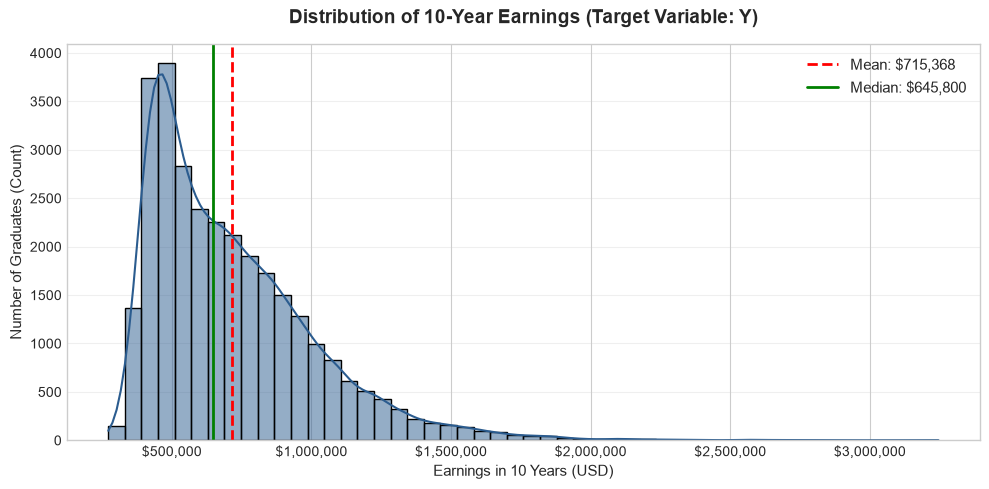

In [26]:
plt.figure(figsize=(10, 5))

# พล็อต Histogram และเส้น KDE
sns.histplot(df_clean['earnings_10yr_usd'], kde=True, bins=50, color='#2b5c8f')

# คำนวณค่าเฉลี่ยและมัธยฐาน
mean_val = df_clean['earnings_10yr_usd'].mean()
median_val = df_clean['earnings_10yr_usd'].median()

# วาดเส้น Mean และ Median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:,.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: ${median_val:,.0f}')

# ตกแต่งกราฟ
plt.title('Distribution of 10-Year Earnings (Target Variable: Y)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Earnings in 10 Years (USD)', fontsize=11)
plt.ylabel('Number of Graduates (Count)', fontsize=11)

# ปรับแกน X ให้อ่านเป็นหลักพัน/หลักล้านง่ายๆ (ใส่เครื่องหมาย comma)
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

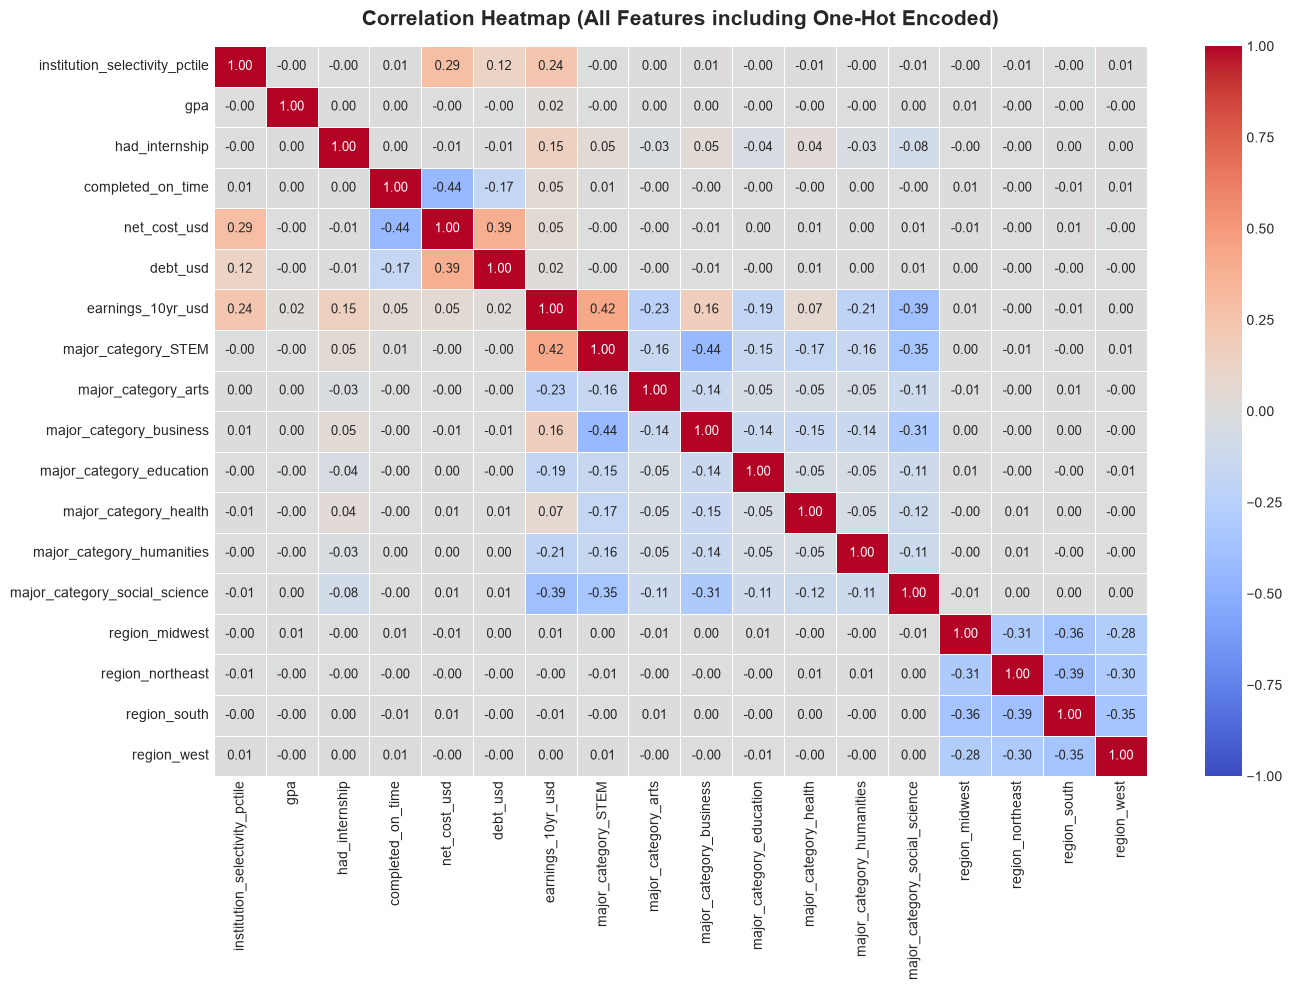

In [27]:
plt.figure(figsize=(14, 10))

# คำนวณ Correlation ของทุกคอลัมน์ใน df_encoded
corr_matrix_all = df_encoded_for_graph.corr()

# พล็อต Heatmap ทั้งหมด
sns.heatmap(
    corr_matrix_all, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    linewidths=0.5,
    annot_kws={"size": 9} # ปรับขนาดตัวเลขข้างในให้พอดี
)

plt.title('Correlation Heatmap (All Features including One-Hot Encoded)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** กลุ่มเราเลือก **Task A (PCA)** เพราะ PCA ครอบคลุมแก่นของ Task C (Covariance/Correlation Analysis) อยู่ในตัวเองอยู่แล้ว — หัวใจของ PCA คือการทำ eigendecomposition ของ covariance matrix ซึ่งเป็น Linear Algebra ล้วน ๆ และเหมาะกับข้อมูลของเราที่หลัง one-hot encoding แล้วมี features ถึง 15 ตัว โดยแต่ละตัวมี scale ต่างกันมาก (ค่าเทอมหลักหมื่น vs เกรด 0-4 vs dummy 0/1) เราจึงอยากตอบคำถามว่าข้อมูลมีโครงสร้างซ้ำซ้อนมากพอที่จะบีบลงเหลือไม่กี่มิติได้หรือไม่ และแต่ละ Principal Component สะท้อนปัจจัยด้านใดของบัณฑิต — Insight ที่คาดว่าจะได้คือจำนวน component ขั้นต่ำที่รักษา variance เดิมไว้ได้ และว่าทิศทางที่ variance สูงที่สุดใช้ทำนายรายได้ได้จริงหรือไม่

ขนาด Feature Matrix X: 30,000 แถว (บัณฑิต) x 15 คอลัมน์ (features)


,PC,Eigenvalue,Explained Variance (%),Cumulative (%)
0,PC1,1.757,11.714,11.714
1,PC2,1.404,9.359,21.072
2,PC3,1.342,8.944,30.016
3,PC4,1.295,8.633,38.649
4,PC5,1.130,7.531,46.180
5,PC6,1.086,7.239,53.419
6,PC7,1.049,6.995,60.414
7,PC8,1.049,6.993,67.408
8,PC9,1.005,6.702,74.110
9,PC10,0.999,6.660,80.769


ต้องใช้ 10 จาก 15 components เพื่อเก็บ variance ไว้ได้ 80%
ต้องใช้ 12 จาก 15 components เพื่อเก็บ variance ไว้ได้ 90%


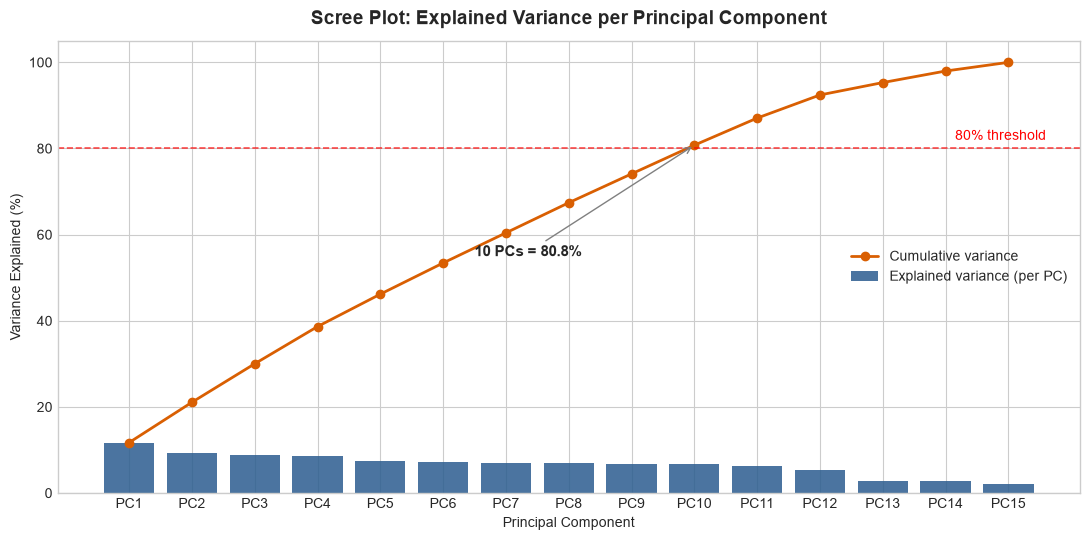

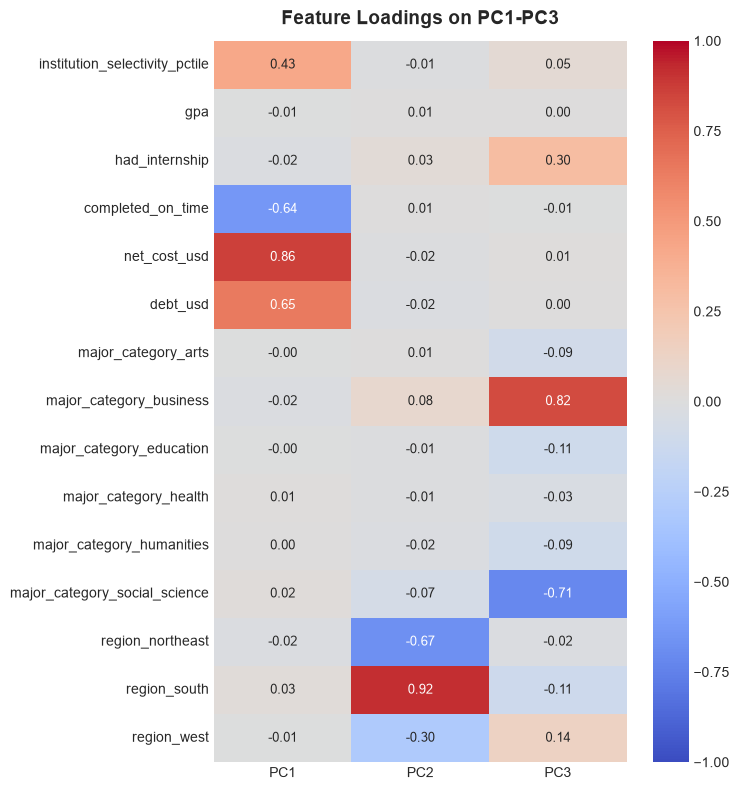

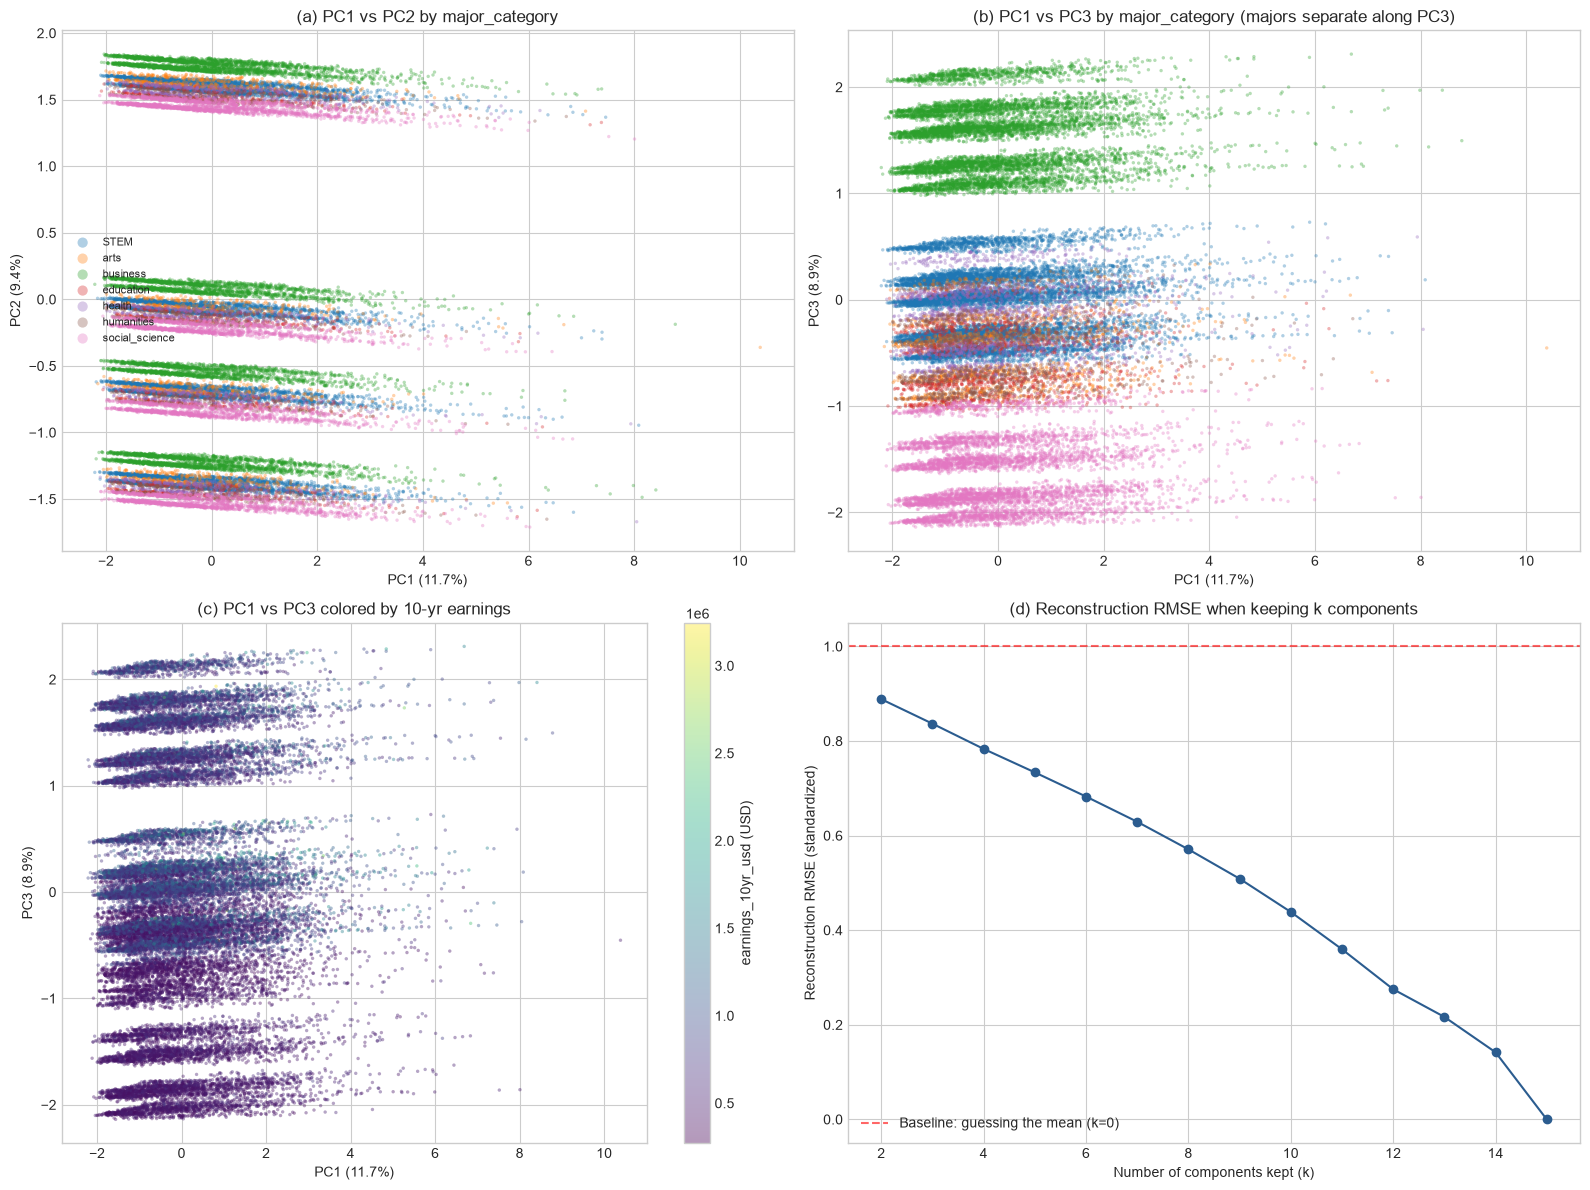

Correlation ระหว่าง PC แต่ละตัวกับรายได้ 10 ปี (8 ตัวแรก):


,corr with earnings_10yr_usd
PC1,0.065
PC2,0.029
PC3,0.400
PC4,-0.035
PC5,0.025
PC6,0.195
PC7,-0.019
PC8,-0.033


In [28]:
# ─── CLO1: Linear Algebra Analysis (Task A: PCA) ─────────────────
# วัตถุประสงค์: ทำ PCA ด้วย Linear Algebra ล้วน ๆ คือสร้าง Covariance Matrix
# และทำ Eigendecomposition ด้วย numpy เอง (ไม่เรียกใช้ sklearn.decomposition.PCA)
# เพื่อลด dimension ของ features และดูว่าโครงสร้างของข้อมูลซ่อนอยู่ตรงไหน

# ── Step 1: สร้าง Feature Matrix X (ตัด target ออกเพื่อป้องกัน Data Leakage) ──
target_col = 'earnings_10yr_usd'
feature_cols = [c for c in df_encoded.columns if c != target_col]
X = df_encoded[feature_cols].values.astype(float)
print(f'ขนาด Feature Matrix X: {X.shape[0]:,} แถว (บัณฑิต) x {X.shape[1]} คอลัมน์ (features)')

# ── Step 2: Standardize ข้อมูลให้มี mean = 0, std = 1 ──
# จำเป็นต้องทำเพราะ scale ของแต่ละ feature ต่างกันมาก (net_cost_usd เป็นหลักหมื่น
# แต่ gpa อยู่แค่ 0-4 และ dummy เป็น 0/1) ถ้าไม่ standardize ทิศทางที่ variance สูงสุด
# จะถูก feature ที่มีตัวเลขใหญ่ที่สุด (ค่าเทอม) ชิงไปทั้งแกน
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# ── Step 3: สร้าง Covariance Matrix แล้วทำ Eigendecomposition ──
# C = (1/(n-1)) * X_scaled.T @ X_scaled  →  C เป็น symmetric matrix เสมอ
n_samples = X_scaled.shape[0]
cov_matrix = (1 / (n_samples - 1)) * X_scaled.T @ X_scaled

# np.linalg.eigh ออกแบบมาสำหรับ symmetric matrix โดยเฉพาะ (เร็วกว่า eig ทั่วไป)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# เรียง eigenvalues/eigenvectors จากมากไปน้อย (PC1 คือทิศทางที่ variance สูงสุด)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# เครื่องหมายของ eigenvector เป็น v หรือ -v ก็ถือเป็นแกนเดียวกัน
# เราจึง fix ให้ feature ที่มี |loading| สูงสุดของแต่ละ PC เป็นบวกเสมอ
# เพื่อให้ผลตีความได้เหมือนกันทุกครั้งที่รัน
for j in range(eigenvectors.shape[1]):
    pivot = np.argmax(np.abs(eigenvectors[:, j]))
    if eigenvectors[pivot, j] < 0:
        eigenvectors[:, j] = -eigenvectors[:, j]

explained_ratio = eigenvalues / eigenvalues.sum()
cumulative_ratio = np.cumsum(explained_ratio)

# ── Step 4: สรุป variance ที่แต่ละ PC เก็บได้ ──
variance_table = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    'Explained Variance (%)': explained_ratio * 100,
    'Cumulative (%)': cumulative_ratio * 100,
}).round(3)
display(variance_table.head(10))

n_80 = int(np.argmax(cumulative_ratio >= 0.80) + 1)
n_90 = int(np.argmax(cumulative_ratio >= 0.90) + 1)
print(f'ต้องใช้ {n_80} จาก {len(eigenvalues)} components เพื่อเก็บ variance ไว้ได้ 80%')
print(f'ต้องใช้ {n_90} จาก {len(eigenvalues)} components เพื่อเก็บ variance ไว้ได้ 90%')

# ── Step 5: Scree Plot ──
fig, ax = plt.subplots(figsize=(11, 5.5))
pc_labels = [f'PC{i+1}' for i in range(len(eigenvalues))]
ax.bar(pc_labels, explained_ratio * 100, color='#2b5c8f', alpha=0.85, label='Explained variance (per PC)')
ax.plot(pc_labels, cumulative_ratio * 100, color='#d95f02', marker='o', linewidth=2, label='Cumulative variance')
ax.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(len(eigenvalues) - 0.4, 82, '80% threshold', color='red', ha='right', fontsize=10)
ax.annotate(f'{n_80} PCs = {cumulative_ratio[n_80-1]*100:.1f}%',
            xy=(n_80 - 1, cumulative_ratio[n_80-1] * 100),
            xytext=(n_80 - 4.5, 55),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=11, fontweight='bold')
ax.set_title('Scree Plot: Explained Variance per Principal Component', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_ylim(0, 105)
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

# ── Step 6: Loadings — ดูว่าแต่ละ PC ประกอบจาก features อะไรบ้าง ──
n_show = 3
loadings = eigenvectors[:, :n_show] * np.sqrt(eigenvalues[:n_show])
loadings_df = pd.DataFrame(loadings, index=feature_cols, columns=[f'PC{i+1}' for i in range(n_show)])

fig, ax = plt.subplots(figsize=(7.5, 8))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Loadings on PC1-PC3', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# ── Step 7: Project ข้อมูลลงระนาบ 2 มิติ (2D Visualization) ──
Z2 = X_scaled @ eigenvectors[:, :2]   # พิกัดใหม่บนระนาบ PC1-PC2
Z3 = X_scaled @ eigenvectors[:, 2]    # แกน PC3 เพิ่มเติม (เหตุผลดูจากผลลัพธ์ข้างล่าง)
pc_pct = explained_ratio * 100

major_labels = df_clean['major_category'].to_numpy()
unique_majors = sorted(df_clean['major_category'].unique())
palette = dict(zip(unique_majors, sns.color_palette('tab10', len(unique_majors))))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) 2 มิติแรกตามตำรา: PC1 vs PC2
ax = axes[0, 0]
for m in unique_majors:
    mask = major_labels == m
    ax.scatter(Z2[mask, 0], Z2[mask, 1], s=6, alpha=0.35, color=palette[m], label=m, edgecolors='none')
ax.set_title('(a) PC1 vs PC2 by major_category')
ax.set_xlabel(f'PC1 ({pc_pct[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({pc_pct[1]:.1f}%)')
ax.legend(fontsize=8, markerscale=3, loc='center left')

# (b) เปลี่ยนแกนที่สองเป็น PC3 — จะเห็นว่าสาขาแยกกันบนแกน PC3 ไม่ใช่ PC2
ax = axes[0, 1]
for m in unique_majors:
    mask = major_labels == m
    ax.scatter(Z2[mask, 0], Z3[mask], s=6, alpha=0.35, color=palette[m], label=m, edgecolors='none')
ax.set_title('(b) PC1 vs PC3 by major_category (majors separate along PC3)')
ax.set_xlabel(f'PC1 ({pc_pct[0]:.1f}%)')
ax.set_ylabel(f'PC3 ({pc_pct[2]:.1f}%)')

# (c) ระบายสีด้วยรายได้จริง — สัญญาณรายได้วิ่งตามแกน PC3
ax = axes[1, 0]
sc = ax.scatter(Z2[:, 0], Z3, s=6, alpha=0.4, c=df_encoded[target_col], cmap='viridis', edgecolors='none')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('earnings_10yr_usd (USD)')
ax.set_title('(c) PC1 vs PC3 colored by 10-yr earnings')
ax.set_xlabel(f'PC1 ({pc_pct[0]:.1f}%)')
ax.set_ylabel(f'PC3 ({pc_pct[2]:.1f}%)')

# (d) ราคาที่ต้องจ่ายเมื่อเก็บข้อมูลไว้แค่ k มิติ (Reconstruction Error)
ax = axes[1, 1]
ks = list(range(2, len(eigenvalues) + 1))
rmses = []
for k in ks:
    Zk = X_scaled @ eigenvectors[:, :k]
    X_approx = Zk @ eigenvectors[:, :k].T
    rmses.append(np.sqrt(((X_scaled - X_approx) ** 2).mean()))
ax.plot(ks, rmses, marker='o', color='#2b5c8f')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Baseline: guessing the mean (k=0)')
ax.set_title('(d) Reconstruction RMSE when keeping k components')
ax.set_xlabel('Number of components kept (k)')
ax.set_ylabel('Reconstruction RMSE (standardized)')
ax.legend()

plt.tight_layout()
plt.show()

# ── Step 8: สัญญาณของ target อยู่บน PC ไหนบ้าง ──
pc_target_corr = pd.Series(
    {f'PC{i+1}': np.corrcoef(X_scaled @ eigenvectors[:, i], df_encoded[target_col])[0, 1]
     for i in range(8)}
).round(3)
print('Correlation ระหว่าง PC แต่ละตัวกับรายได้ 10 ปี (8 ตัวแรก):')
display(pc_target_corr.to_frame('corr with earnings_10yr_usd'))

**Insight จาก CLO1 Analysis:**

**1. Variance กระจายเกือบเท่ากันทุกทิศทาง — การลดมิติทำได้จำกัด**
PC1 อธิบาย variance ได้เพียง ~11.7% และต้องใช้ถึง **10 จาก 15 components** จึงจะเก็บ variance ไว้ได้ 80% (12 components สำหรับ 90%) แปลว่า covariance matrix หลัง standardize มี eigenvalues ใกล้ 1 เกือบทุกแกน หรือก็คือ features ของเราแทบไม่มี correlation ระหว่างกันเลย การ reconstruct ข้อมูลจากเพียง 2 components จึงคลาดเคลื่อน RMSE ≈ 0.89 ในหน่วย standardized (เสียข้อมูลราว 79% — ดูเส้นกราฟ (d))

**2. สามแกนหลักของข้อมูลมีความหมายชัดเจน (จาก Loadings heatmap):**
- **PC1 (11.7%) = แกน "ต้นทุนการศึกษา"** — net_cost_usd (+0.86), debt_usd (+0.65) และ institution_selectivity_pctile (+0.43) วิ่งไปด้วยกัน แต่ completed_on_time โหลดสวนทาง (-0.64) สะท้อนว่าบัณฑิตที่เรียนในสถาบันที่แพงและคัดเลือกยากมักมีหนี้สูง และจบตามกำหนดเวลาน้อยลง (corr(net_cost, on_time) = -0.44)
- **PC2 (9.4%) = แกน "ภูมิภาค"** — region_south (+0.92) สวนทางกับ region_northeast (-0.67) และ region_west (-0.30)
- **PC3 (8.9%) = แกน "สาขาวิชา"** — business (+0.82) สวนทางกับ social_science (-0.71) โดย had_internship เอนไปทางฝั่ง business (+0.30)

**3. สัญญาณรายได้ไม่ได้อยู่บน PC ที่ variance สูงสุด (บทเรียนสำคัญของ PCA)**
corr(PC1, รายได้) ≈ 0.07 เกือบเป็นศูนย์ แต่ **PC3 ที่อธิบาย variance แค่ 8.9% กลับมี correlation กับรายได้ถึง +0.40** (ฝั่ง business มีรายได้สูงกว่า — เห็นไล่ระดับสีชัดในกราฟ (c)) และ PC6 ซึ่งเป็นแกน health + internship ก็มี corr ≈ +0.20 นี่คือหลักฐานว่า **PCA เลือกทิศทางที่ variance สูงสุด ซึ่งไม่จำเป็นต้องเป็นทิศทางที่ทำนาย target ได้ดีที่สุด** ดังนั้นหากนำ PCA มาลดมิติก่อนสร้างโมเดล การตัด PC ตัวท้าย ๆ ทิ้งเพียงเพราะ variance ต่ำ อาจทิ้งปัจจัยสำคัญที่สุดต่อรายได้ (สาขาวิชา) หายไปด้วย — ข้อสังเกตนี้จะนำไปพิจารณาต่อในการเลือก features ของ Part 3-4

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

**คำตอบ:** Dataset นี้เหมาะกับ **Regression** เพราะ target คือ `earnings_10yr_usd` ซึ่งเป็นตัวแปรต่อเนื่อง (continuous) ที่มีลำดับและระยะห่างที่มีความหมายจริงในหน่วยดอลลาร์ — โจทย์ของเราคือการทำนาย "จำนวนเงิน" ไม่ใช่การจัดกลุ่ม การบังคับให้เป็น Classification (เช่น แบ่งรายได้เป็น สูง/กลาง/ต่ำ) จะเป็นการทิ้งข้อมูลความละเอียด (information loss) โดยไม่จำเป็น ส่วนคอลัมน์ที่มีลักษณะเหมาะกับ Classification อยู่แล้ว (positive_roi, high_roi) เราตัดออกตั้งแต่ Part 1 เพราะเป็นผลลัพธ์ที่คำนวณจาก target โดยตรง (Data Leakage) ดังนั้นทุกส่วนถัดไปของโปรเจกต์จะใช้ Regression metrics (MSE / R²) ในการวัดผล

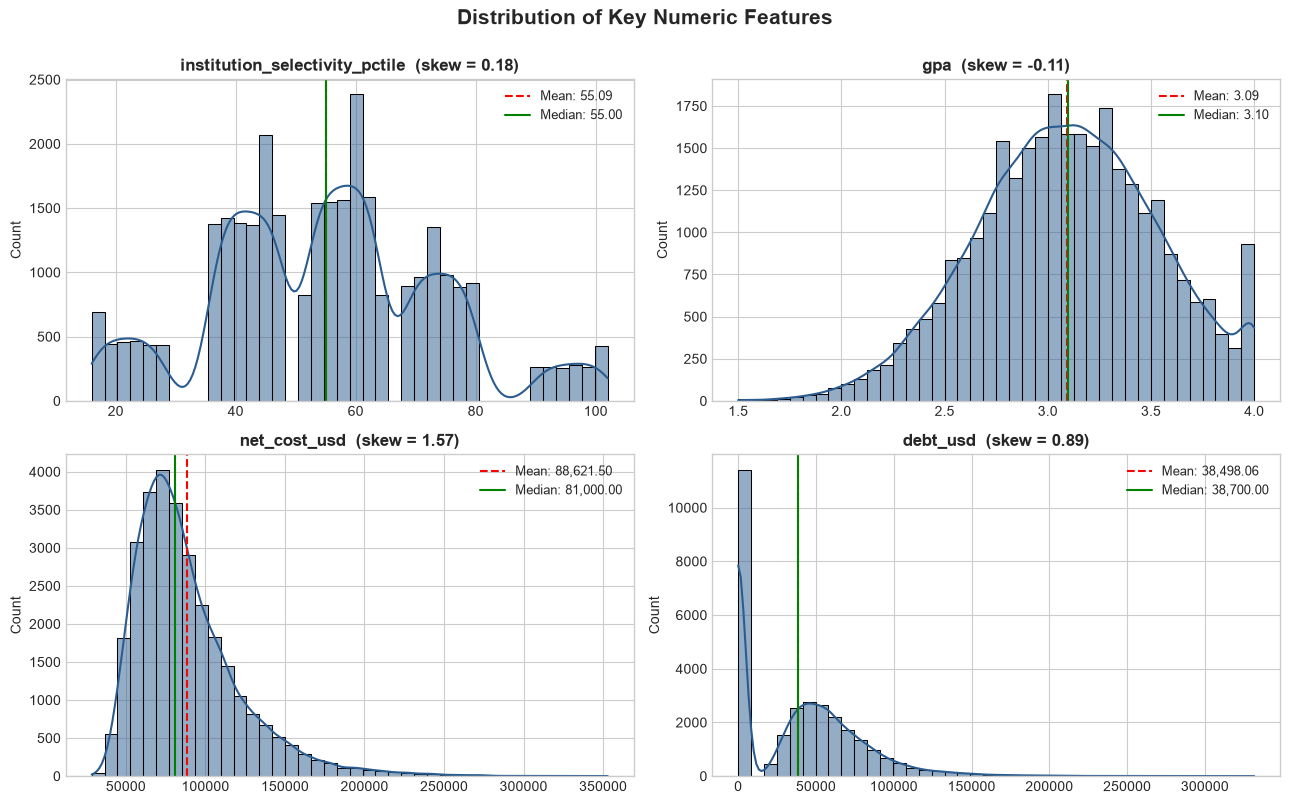

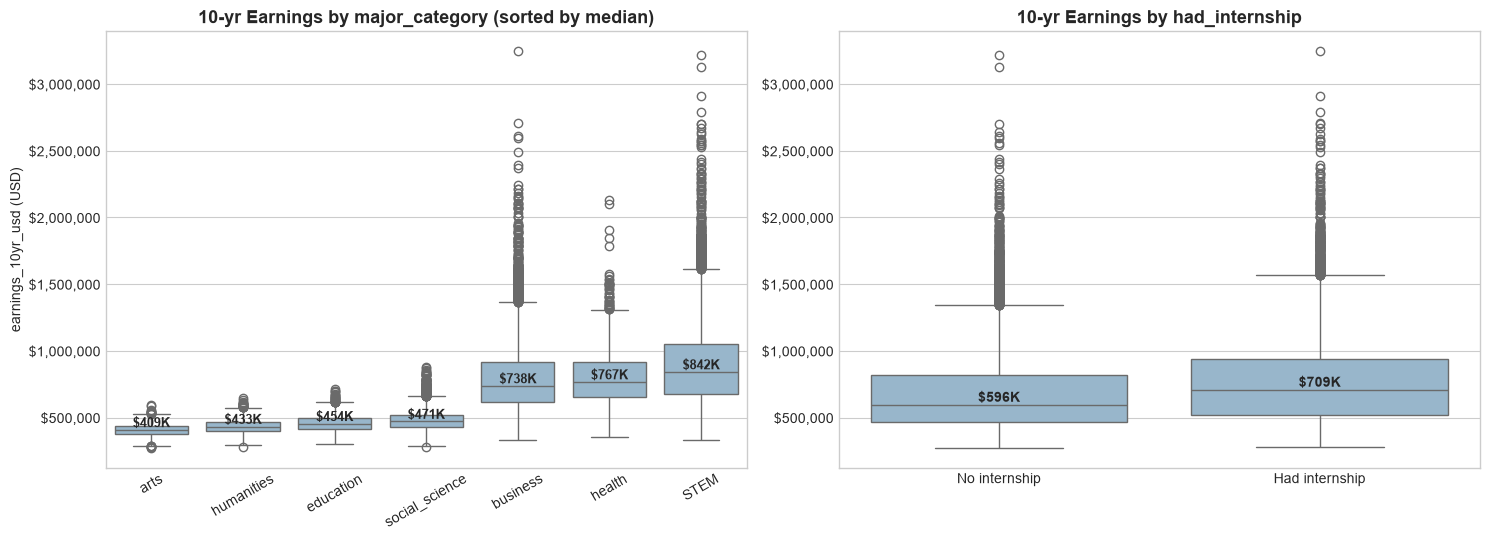

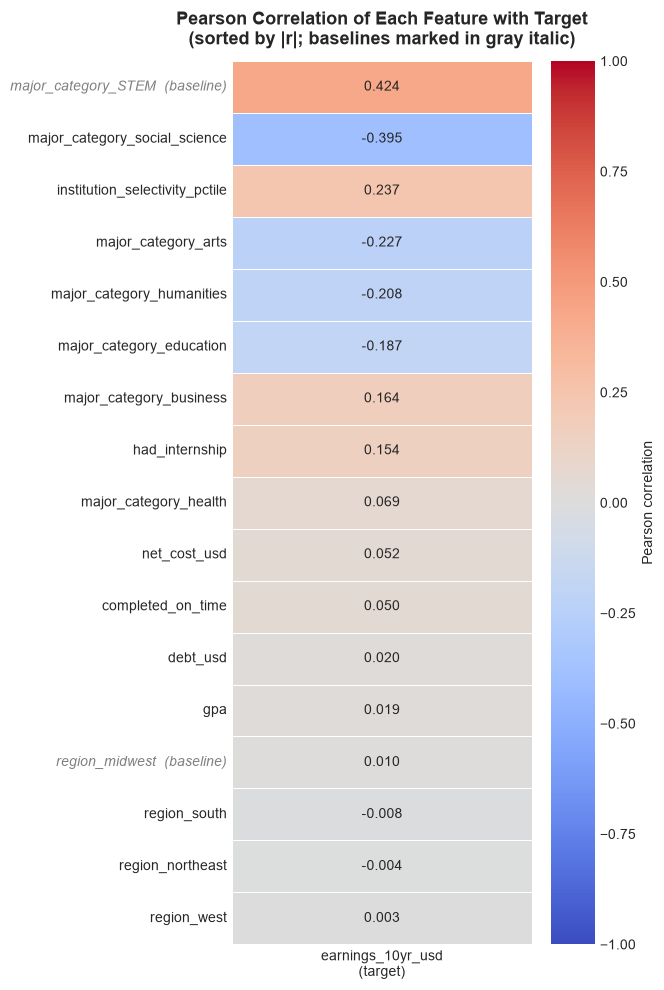

Baseline (mean predictor): test MSE = 8.940e+10 (RMSE = $298,996)

Polynomial regression (feature = institution_selectivity_pctile):


,degree,train MSE,test MSE
0,1,8.360000e+10,8.410000e+10
1,2,8.360000e+10,8.400000e+10
2,3,8.350000e+10,8.400000e+10
3,4,8.350000e+10,8.400000e+10
4,5,8.360000e+10,8.400000e+10
5,6,8.370000e+10,8.410000e+10
6,7,8.380000e+10,8.430000e+10
7,8,8.400000e+10,8.440000e+10
8,9,8.460000e+10,8.510000e+10
9,10,8.480000e+10,8.530000e+10


Decision Tree (all 15 features):


,max_depth,train MSE,test MSE
0,1,7.470000e+10,7.550000e+10
1,2,6.820000e+10,6.830000e+10
2,3,6.180000e+10,6.110000e+10
3,4,5.530000e+10,5.540000e+10
4,5,5.170000e+10,5.140000e+10
5,6,4.960000e+10,4.910000e+10
6,7,4.800000e+10,4.770000e+10
7,8,4.700000e+10,4.770000e+10
8,9,4.610000e+10,4.680000e+10
9,10,4.520000e+10,4.770000e+10


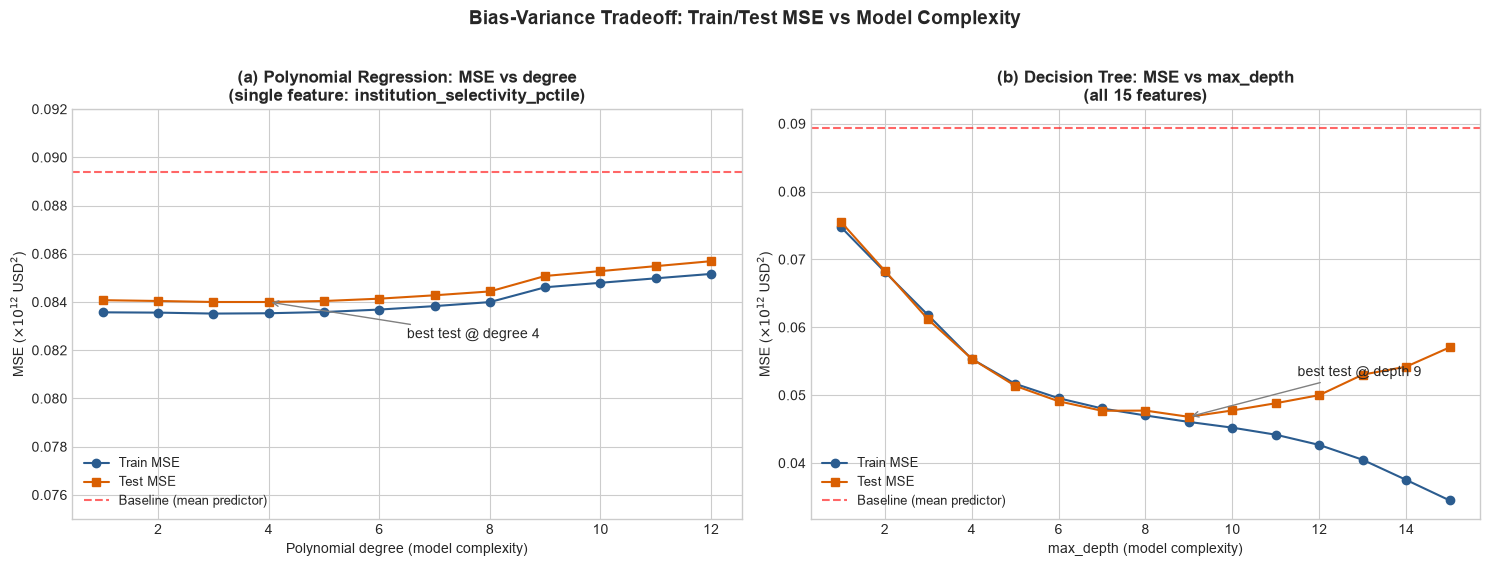

Best polynomial: degree 4, test MSE = 8.400e+10 (RMSE = $289,828)
Best decision tree: max_depth 9, test MSE = 4.681e+10 (RMSE = $216,348)
Tree ที่ depth สูงกว่าจุด optimal จะ overfit — train MSE ยังลดแต่ test MSE กลับเพิ่มขึ้น


In [29]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset
# 1) Distribution ของ numeric features สำคัญ  2) Features ที่ correlate กับ target
# 3) Train/Test MSE ตามระดับความซับซ้อนของโมเดล (Bias-Variance Tradeoff)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# ── Step 1: Distribution ของ numeric features สำคัญ ──
num_cols = ['institution_selectivity_pctile', 'gpa', 'net_cost_usd', 'debt_usd']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df_clean[col], kde=True, bins=40, color='#2b5c8f', ax=ax)
    m, md = df_clean[col].mean(), df_clean[col].median()
    ax.axvline(m, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {m:,.2f}')
    ax.axvline(md, color='green', linewidth=1.5, label=f'Median: {md:,.2f}')
    ax.set_title(f'{col}  (skew = {df_clean[col].skew():.2f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)
plt.suptitle('Distribution of Key Numeric Features', fontsize=15, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# ── Step 2: Boxplot รายได้แยกตามกลุ่ม (สาขา / internship) ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
major_order = df_clean.groupby('major_category')[target_col].median().sort_values().index.tolist()
sns.boxplot(data=df_clean, x='major_category', y=target_col, order=major_order, color='#8fb8d4', ax=axes[0])
for i, mjr in enumerate(major_order):
    med = df_clean.loc[df_clean['major_category'] == mjr, target_col].median()
    axes[0].text(i, med, f'${med/1000:,.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('10-yr Earnings by major_category (sorted by median)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('earnings_10yr_usd (USD)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter('${x:,.0f}')

sns.boxplot(data=df_clean, x='had_internship', y=target_col, color='#8fb8d4', ax=axes[1])
for i, v in enumerate([0, 1]):
    med = df_clean.loc[df_clean['had_internship'] == v, target_col].median()
    axes[1].text(i, med, f'${med/1000:,.0f}K', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No internship', 'Had internship'])
axes[1].set_title('10-yr Earnings by had_internship', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter('${x:,.0f}')
plt.tight_layout()
plt.show()

# ── Step 3: Correlation ของทุก feature กับ target (heatmap เรียงตาม |r|) ──
# ใช้ df_encoded_for_graph (one-hot แบบเก็บครบทุกกลุ่ม) เพื่อให้เห็น baseline ด้วย:
# major_category_STEM และ region_midwest (ติดป้าย "baseline") ไม่ได้ถูกใช้ในโมเดล
# — feature อื่นๆ ตีความโดยเทียบกับสองตัวนี้ และค่า r ของ STEM คือภาพสะท้อนจาก
# ฝั่งตรงข้ามของกลุ่มสาขารายได้ต่ำ (ทางคณิต STEM = 1 − ผลรวมของสาขาอื่น)
corr = df_encoded_for_graph.drop(columns=[target_col]).corrwith(df_encoded_for_graph[target_col])
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
corr_labels = [f'{name}  (baseline)' if name in ('major_category_STEM', 'region_midwest') else name
               for name in corr.index]

fig, ax = plt.subplots(figsize=(6.5, 10))
sns.heatmap(corr.to_frame('earnings_10yr_usd\n(target)').set_axis(corr_labels),
            annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 10},
            cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Pearson Correlation of Each Feature with Target\n(sorted by |r|; baselines marked in gray italic)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel(''); ax.set_ylabel('')
for lbl in ax.get_yticklabels():
    if '(baseline)' in lbl.get_text():
        lbl.set_color('gray')
        lbl.set_fontstyle('italic')
plt.tight_layout()
plt.show()

# ── Step 4: Bias-Variance Tradeoff — Train/Test MSE ตาม model complexity ──
# ทดลอง 2 แบบ: (a) Polynomial Regression บน feature เชิงตัวเลขที่ correlate สูงสุด
#               (b) Decision Tree ที่ใช้ feature ทั้งหมด เพิ่ม max_depth = ความซับซ้อน
X_all = df_encoded[feature_cols].values.astype(float)
y = df_encoded[target_col].values.astype(float)
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Baseline: ทายด้วยค่าเฉลี่ยล้วน ๆ (ถ้าโมเดลแย่กว่านี้แปลว่าไม่มีประโยชน์)
baseline_mse = mean_squared_error(y_te, np.full(len(y_te), y_tr.mean()))
print(f'Baseline (mean predictor): test MSE = {baseline_mse:.3e} (RMSE = ${np.sqrt(baseline_mse):,.0f})')

top_cont = 'institution_selectivity_pctile'
xi_tr = X_tr[:, feature_cols.index(top_cont)].reshape(-1, 1)
xi_te = X_te[:, feature_cols.index(top_cont)].reshape(-1, 1)
poly_rows = []
for d in range(1, 13):
    pf = PolynomialFeatures(degree=d, include_bias=False)
    model = LinearRegression().fit(pf.fit_transform(xi_tr), y_tr)
    poly_rows.append({
        'degree': d,
        'train MSE': mean_squared_error(y_tr, model.predict(pf.transform(xi_tr))),
        'test MSE': mean_squared_error(y_te, model.predict(pf.transform(xi_te))),
    })
poly_df = pd.DataFrame(poly_rows)

tree_rows = []
for dpt in range(1, 16):
    model = DecisionTreeRegressor(max_depth=dpt, random_state=42).fit(X_tr, y_tr)
    tree_rows.append({
        'max_depth': dpt,
        'train MSE': mean_squared_error(y_tr, model.predict(X_tr)),
        'test MSE': mean_squared_error(y_te, model.predict(X_te)),
    })
tree_df = pd.DataFrame(tree_rows)

print(f'\nPolynomial regression (feature = {top_cont}):')
display(poly_df.round({'train MSE': -8, 'test MSE': -8}))
print('Decision Tree (all 15 features):')
display(tree_df.round({'train MSE': -8, 'test MSE': -8}))

# พล็อตเป็น MSE หน่วย ×10¹² USD² (MSE ค่าดิบเป็นหลักแสนล้าน เลขยาวเกินไป)
scale = 1e12
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.plot(poly_df['degree'], poly_df['train MSE'] / scale, marker='o', color='#2b5c8f', label='Train MSE')
ax.plot(poly_df['degree'], poly_df['test MSE'] / scale, marker='s', color='#d95f02', label='Test MSE')
ax.axhline(baseline_mse / scale, color='red', linestyle='--', alpha=0.6, label='Baseline (mean predictor)')
best_d = int(poly_df.loc[poly_df['test MSE'].idxmin(), 'degree'])
ax.annotate(f'best test @ degree {best_d}',
            xy=(best_d, poly_df.loc[poly_df['degree'] == best_d, 'test MSE'].iloc[0] / scale),
            xytext=(best_d + 2.5, poly_df['test MSE'].min() / scale - 0.0015),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax.set_title('(a) Polynomial Regression: MSE vs degree\n(single feature: ' + top_cont + ')', fontsize=12, fontweight='bold')
ax.set_xlabel('Polynomial degree (model complexity)')
ax.set_ylabel('MSE ($\\times 10^{12}$ USD$^2$)')
ax.set_ylim(0.075, 0.092)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(tree_df['max_depth'], tree_df['train MSE'] / scale, marker='o', color='#2b5c8f', label='Train MSE')
ax.plot(tree_df['max_depth'], tree_df['test MSE'] / scale, marker='s', color='#d95f02', label='Test MSE')
ax.axhline(baseline_mse / scale, color='red', linestyle='--', alpha=0.6, label='Baseline (mean predictor)')
best_t = int(tree_df.loc[tree_df['test MSE'].idxmin(), 'max_depth'])
ax.annotate(f'best test @ depth {best_t}',
            xy=(best_t, tree_df.loc[tree_df['max_depth'] == best_t, 'test MSE'].iloc[0] / scale),
            xytext=(best_t + 2.5, tree_df['test MSE'].min() / scale + 0.006),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax.set_title('(b) Decision Tree: MSE vs max_depth\n(all 15 features)', fontsize=12, fontweight='bold')
ax.set_xlabel('max_depth (model complexity)')
ax.set_ylabel('MSE ($\\times 10^{12}$ USD$^2$)')
ax.legend(fontsize=9)

plt.suptitle('Bias-Variance Tradeoff: Train/Test MSE vs Model Complexity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_poly_mse = poly_df['test MSE'].min()
best_tree_mse = tree_df['test MSE'].min()
print(f'Best polynomial: degree {best_d}, test MSE = {best_poly_mse:.3e} (RMSE = ${np.sqrt(best_poly_mse):,.0f})')
print(f'Best decision tree: max_depth {best_t}, test MSE = {best_tree_mse:.3e} (RMSE = ${np.sqrt(best_tree_mse):,.0f})')
print(f'Tree ที่ depth สูงกว่าจุด optimal จะ overfit — train MSE ยังลดแต่ test MSE กลับเพิ่มขึ้น')

**Insight จาก CLO2 Analysis:**

**1. Features สำคัญต่อรายได้ (จาก Correlation heatmap)**
- Heatmap นี้ใช้ one-hot แบบเก็บครบทุกกลุ่ม เพื่อให้เห็น baseline ด้วย — ค่า |r| สูงสุดในภาพคือ **major_category_STEM (+0.42)** แต่ตัวนี้ติดป้าย baseline เพราะ**ไม่ได้ถูกใช้ในโมเดล** และเป็นเพียง "ภาพสะท้อนจากฝั่งตรงข้าม" ของกลุ่มสาขารายได้ต่ำ (ทางคณิต STEM = 1 − ผลรวมสาขาอื่น) — ตัวที่อยู่ในโมเดลจริงที่แรงที่สุดคือ **major_category_social_science (r = -0.40)**
- "สาขาวิชา" โดยรวมคือปัจจัยแรงที่สุด: กลุ่มรายได้สูง (STEM +0.42, business +0.16, health +0.07) ขัดขั้วกับกลุ่มรายได้ต่ำ (social_science -0.40, arts -0.23, humanities -0.21, education -0.19) — ส่วน region ทุกภูมิภาครวมถึง midwest (+0.01) แทบเป็นศูนย์
- ตัวแปรต่อเนื่องที่แรงที่สุดคือ **institution_selectivity_pctile (r = +0.24)** ตามด้วย **had_internship (+0.15)**
- ที่น่าประหลาดใจคือ **gpa (r = +0.02) และ debt_usd (+0.02) แทบไม่มีอิทธิพล** และ region ไม่มีผลเลยทุกภูมิภาค — สิ่งที่กำหนดรายได้ไม่ใช่เกรดหรือภูมิภาค แต่คือ "เรียนสาขาอะไร" (boxplot ยืนยัน: median ของ STEM $842K ≈ 2.1 เท่าของ arts $409K และการมี internship เพิ่ม median ~$113K)

**2. Distribution ของ target และ features**
- `earnings_10yr_usd` **เบ้ขวา** (skew = +1.46, mean $715K > median $646K, หางยาวถึง $3.2M) → ใน Part 4 ควรพิจารณา log-transform ของ target เพื่อช่วยโมเดลเชิงเส้น
- net_cost_usd เบ้ขวา (skew = 1.57), debt_usd มี spike แรงที่ 0 (บัณฑิตจำนวนมากไม่มีหนี้), institution_selectivity_pctile มีโครงสร้างแบบกลุ่ม (multimodal) สอดคล้องกับที่ institution_tier ถูกแบ่งจากค่านี้ และ gpa ค่อนข้าง normal

**3. Bias-Variance: optimal complexity อยู่ที่เท่าไหร่?**
- **Polynomial (feature เดียว):** test MSE แบนราบราว 8.4×10¹⁰ (RMSE ~$290K) ตลอด degree 1-12 — การเพิ่ม degree ไม่ช่วยลด bias เลยและเริ่ม overfit เล็กน้อยหลัง degree ~5 → คอขวดของโมเดลนี้คือ **underfitting (high bias)** เพราะ feature เดียว + ความสัมพันธ์อ่อน ไม่ใช่ variance
- **Decision Tree (ทุก features):** ได้ U-curve ชัดเจน — test MSE ต่ำสุดที่ **max_depth ≈ 9** (MSE 4.68×10¹⁰, RMSE $216K ลดลงจาก baseline $299K ราว 28%) จากนั้น train MSE ยังลดต่อแต่ test MSE พุ่งขึ้นชัดเจน → **overfitting (high variance)** เกิดขึ้นเมื่อต้นไม้ลึกเกินไป
- บทสรุป: ความสัมพันธ์ในข้อมูลเป็นแบบ **non-linear/เชิงกลุ่ม** (ตัดสินด้วยกฎ if-else ตามสาขา/ความยากของมหาวิทยาลัยได้ดีกว่าสมการเส้นตรง) โมเดลตระกูล Tree หรือ KNN น่าจะทำได้ดีกว่า Linear Regression — เป็นตัวตั้งต้นที่ดีสำหรับการเปรียบเทียบโมเดลใน Part 4

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ✅ Regression (เหตุผล: ดูคำตอบใน Part 3)  ⬜ Classification

═══ Model 1: Simple Linear Regression ═══
Feature ที่ใช้: major_category_social_science (|r| สูงสุดจาก Part 3)
Intercept (β0) = $774,283  ← ค่าทำนายของบัณฑิตกลุ่มอื่น (non social_science)
Coefficient (β1) = $-294,630  ← สาย social_science ต่ำกว่ากลุ่มอื่นเฉลี่ย $294,630
Train: MSE = 7.471e+10, R² = 0.1557
Test:  MSE = 7.546e+10, R² = 0.1558 (RMSE = $274,709)


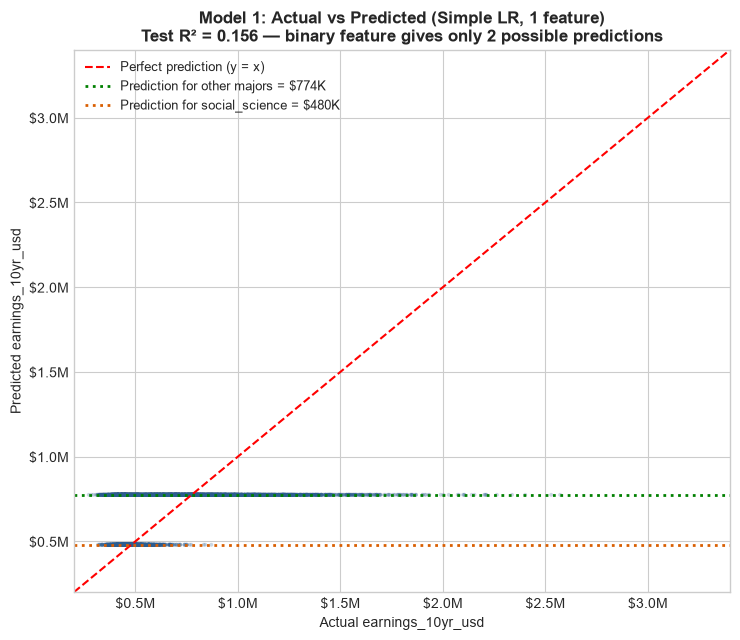

In [30]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: Simple Linear Regression ด้วย feature เดียวที่ correlate กับ target สูงสุด
# จากการวิเคราะห์ใน Part 3 feature ที่มี |r| สูงสุดคือ major_category_social_science (r = -0.40)
# (ส่วน institution_selectivity_pctile +0.24 เป็นตัวแปรต่อเนื่องที่สูงสุด)
from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ใช้ train/test split ชุดเดียวกับ Part 3 (random_state=42) เพื่อให้เปรียบเทียบกันได้
X_all = df_encoded[feature_cols].values.astype(float)
y = df_encoded[target_col].values.astype(float)
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y, test_size=0.2, random_state=42)

top_feature = 'major_category_social_science'
fi = feature_cols.index(top_feature)
model1 = LinearRegression().fit(X_tr[:, [fi]], y_tr)
pred1_tr = model1.predict(X_tr[:, [fi]])
pred1_te = model1.predict(X_te[:, [fi]])

print('═══ Model 1: Simple Linear Regression ═══')
print(f'Feature ที่ใช้: {top_feature} (|r| สูงสุดจาก Part 3)')
print(f'Intercept (β0) = ${model1.intercept_:,.0f}  ← ค่าทำนายของบัณฑิตกลุ่มอื่น (non social_science)')
print(f'Coefficient (β1) = ${model1.coef_[0]:,.0f}  ← สาย social_science ต่ำกว่ากลุ่มอื่นเฉลี่ย ${-model1.coef_[0]:,.0f}')
m1_train = {'MSE': mean_squared_error(y_tr, pred1_tr), 'R2': r2_score(y_tr, pred1_tr)}
m1_test = {'MSE': mean_squared_error(y_te, pred1_te), 'R2': r2_score(y_te, pred1_te)}
print(f'Train: MSE = {m1_train["MSE"]:.3e}, R² = {m1_train["R2"]:.4f}')
print(f'Test:  MSE = {m1_test["MSE"]:.3e}, R² = {m1_test["R2"]:.4f} (RMSE = ${np.sqrt(m1_test["MSE"]):,.0f})')

money = FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
lims = [2e5, 3.4e6]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(y_te, pred1_te, s=8, alpha=0.25, color='#2b5c8f', edgecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y = x)')
ax.axhline(model1.intercept_, color='green', linestyle=':', linewidth=2,
           label=f'Prediction for other majors = ${model1.intercept_/1000:,.0f}K')
ax.axhline(model1.intercept_ + model1.coef_[0], color='#d95f02', linestyle=':', linewidth=2,
           label=f'Prediction for social_science = ${(model1.intercept_ + model1.coef_[0])/1000:,.0f}K')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.xaxis.set_major_formatter(money); ax.yaxis.set_major_formatter(money)
ax.set_xlabel('Actual earnings_10yr_usd')
ax.set_ylabel('Predicted earnings_10yr_usd')
ax.set_title(f'Model 1: Actual vs Predicted (Simple LR, 1 feature)\n'
             f'Test R² = {m1_test["R2"]:.3f} — binary feature gives only 2 possible predictions',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

═══ Model 2: Multiple Linear Regression (ทุก features) ═══
Train: MSE = 4.816e+10, R² = 0.4558
Test:  MSE = 4.755e+10, R² = 0.4681 (RMSE = $218,055)


,Coefficient (USD per unit),Std. Coef. (USD per 1 SD)
major_category_social_science,-407516.5,-162379.3
major_category_arts,-480424.3,-100119.5
major_category_humanities,-454449.8,-94995.0
major_category_education,-425200.9,-89226.7
institution_selectivity_pctile,3680.5,68365.4
major_category_business,-101687.9,-45584.8
had_internship,53138.3,26356.3
major_category_health,-92576.0,-20870.5
completed_on_time,30778.3,14358.3
gpa,11145.3,4875.0


หมายเหตุ: baseline ของ major_category คือ STEM และของ region คือ midwest (drop_first=True)
→ Coefficient ของ dummy แต่ละตัวจึงตีความเทียบกับกลุ่ม baseline

═══ Model 2b (เสริม): Multiple LR + log target (smearing factor = 1.0314) ═══
Train: MSE = 4.740e+10, R² = 0.4644
Test:  MSE = 4.673e+10, R² = 0.4773 (RMSE = $216,165)


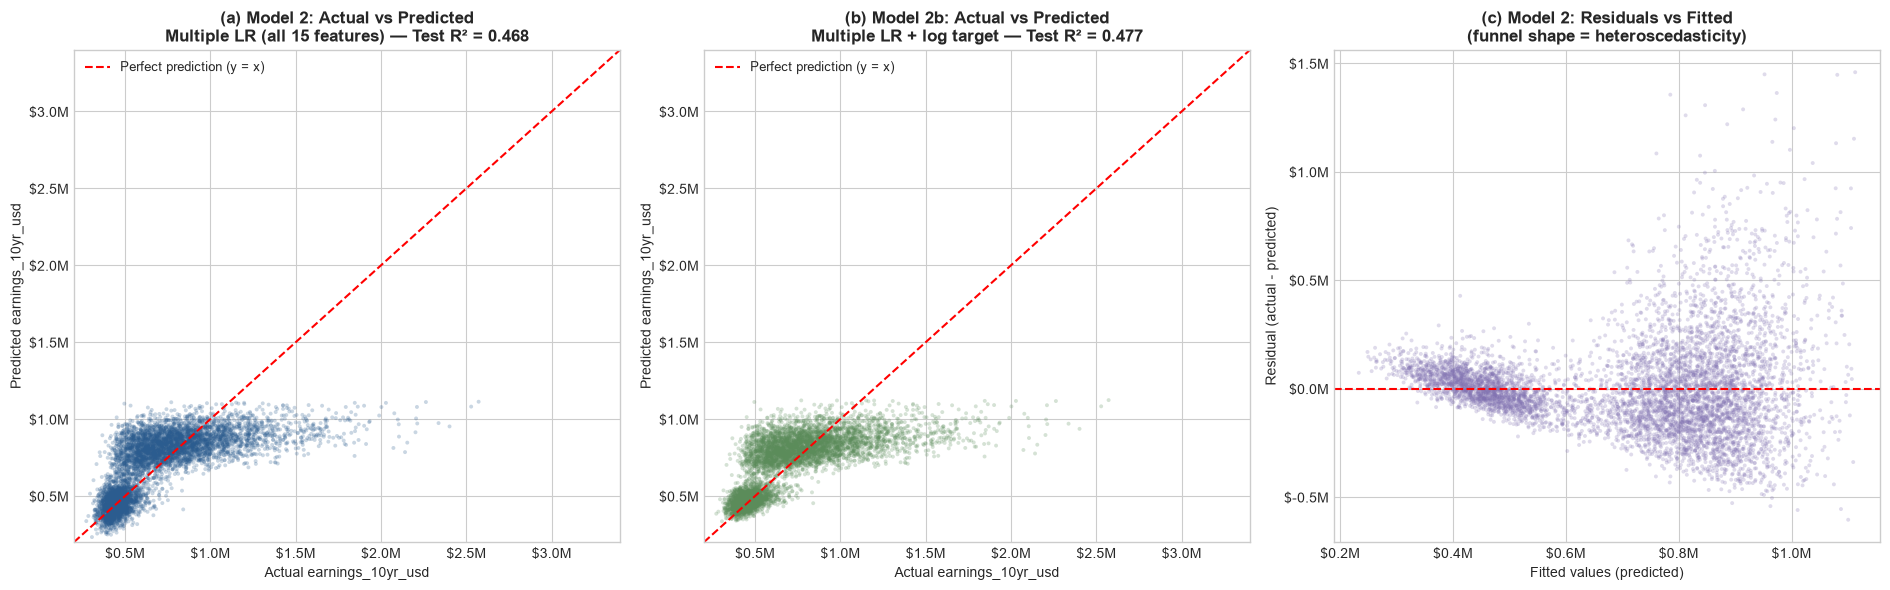

In [31]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: Multiple Linear Regression ใช้ feature ทั้งหมด 15 ตัว (หลัง one-hot encoding)
# พร้อมแสดง coefficients, MSE, R², Actual vs Predicted plot
# และทดลองเสริม: log-transform ของ target (ตามข้อสังเกต skew จาก Part 3)
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model2 = LinearRegression().fit(X_tr, y_tr)
pred2_tr = model2.predict(X_tr)
pred2_te = model2.predict(X_te)
m2_train = {'MSE': mean_squared_error(y_tr, pred2_tr), 'R2': r2_score(y_tr, pred2_tr)}
m2_test = {'MSE': mean_squared_error(y_te, pred2_te), 'R2': r2_score(y_te, pred2_te)}

print('═══ Model 2: Multiple Linear Regression (ทุก features) ═══')
print(f'Train: MSE = {m2_train["MSE"]:.3e}, R² = {m2_train["R2"]:.4f}')
print(f'Test:  MSE = {m2_test["MSE"]:.3e}, R² = {m2_test["R2"]:.4f} (RMSE = ${np.sqrt(m2_test["MSE"]):,.0f})')

# ── Coefficients: เทียบน้ำหนักของแต่ละ feature ──
# เนื่องจาก scale ต่างกัน (ค่าเทอมเป็นหมื่น vs dummy เป็น 0/1) เราจึงคำนวณ
# Standardized Coefficient = สัมประสิทธิ์เมื่อ standardize X (หน่วย: USD ต่อ 1 SD ของ feature นั้น)
# เพื่อให้เทียบ "ความสำคัญ" ข้าม feature ได้อย่างเป็นธรรม
mu, sd = X_tr.mean(axis=0), X_tr.std(axis=0)
model2z = LinearRegression().fit((X_tr - mu) / sd, y_tr)
coef_table = pd.DataFrame({
    'Coefficient (USD per unit)': model2.coef_,
    'Std. Coef. (USD per 1 SD)': model2z.coef_,
}, index=feature_cols)
coef_table = coef_table.reindex(
    coef_table['Std. Coef. (USD per 1 SD)'].abs().sort_values(ascending=False).index
).round(1)
display(coef_table)
print('หมายเหตุ: baseline ของ major_category คือ STEM และของ region คือ midwest (drop_first=True)')
print('→ Coefficient ของ dummy แต่ละตัวจึงตีความเทียบกับกลุ่ม baseline')

# ── Model 2b (เสริม): log-transform target + Duan smearing ──
# จาก Part 3 target เบ้ขวา (skew 1.46) การ fit บน log(y) มักช่วยให้ linear model เข้ากับข้อมูลขึ้น
# และต้องแปลงกลับด้วย exp พร้อม smearing factor เพื่อแก้ retransformation bias
y_log_tr = np.log(y_tr)
model2log = LinearRegression().fit(X_tr, y_log_tr)
smear = np.mean(np.exp(y_log_tr - model2log.predict(X_tr)))
pred2b_tr = np.exp(model2log.predict(X_tr)) * smear
pred2b_te = np.exp(model2log.predict(X_te)) * smear
m2b_train = {'MSE': mean_squared_error(y_tr, pred2b_tr), 'R2': r2_score(y_tr, pred2b_tr)}
m2b_test = {'MSE': mean_squared_error(y_te, pred2b_te), 'R2': r2_score(y_te, pred2b_te)}
print(f'\n═══ Model 2b (เสริม): Multiple LR + log target (smearing factor = {smear:.4f}) ═══')
print(f'Train: MSE = {m2b_train["MSE"]:.3e}, R² = {m2b_train["R2"]:.4f}')
print(f'Test:  MSE = {m2b_test["MSE"]:.3e}, R² = {m2b_test["R2"]:.4f} (RMSE = ${np.sqrt(m2b_test["MSE"]):,.0f})')

money = FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
lims = [2e5, 3.4e6]
residuals = y_te - pred2_te

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

ax = axes[0]
ax.scatter(y_te, pred2_te, s=8, alpha=0.25, color='#2b5c8f', edgecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y = x)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.xaxis.set_major_formatter(money); ax.yaxis.set_major_formatter(money)
ax.set_xlabel('Actual earnings_10yr_usd'); ax.set_ylabel('Predicted earnings_10yr_usd')
ax.set_title(f'(a) Model 2: Actual vs Predicted\nMultiple LR (all 15 features) — Test R² = {m2_test["R2"]:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')

ax = axes[1]
ax.scatter(y_te, pred2b_te, s=8, alpha=0.25, color='#5b8c5a', edgecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y = x)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.xaxis.set_major_formatter(money); ax.yaxis.set_major_formatter(money)
ax.set_xlabel('Actual earnings_10yr_usd'); ax.set_ylabel('Predicted earnings_10yr_usd')
ax.set_title(f'(b) Model 2b: Actual vs Predicted\nMultiple LR + log target — Test R² = {m2b_test["R2"]:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')

ax = axes[2]
ax.scatter(pred2_te, residuals, s=8, alpha=0.25, color='#8172b2', edgecolors='none')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.xaxis.set_major_formatter(money); ax.yaxis.set_major_formatter(money)
ax.set_xlabel('Fitted values (predicted)')
ax.set_ylabel('Residual (actual - predicted)')
ax.set_title('(c) Model 2: Residuals vs Fitted\n(funnel shape = heteroscedasticity)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
|-------|-------------|------------|----------|
| Baseline (ทายค่าเฉลี่ยล้วน) | MSE 8.85×10¹⁰, R² = 0 | MSE 8.94×10¹⁰, R² ≈ 0 (RMSE $299K) | จุดอ้างอิง — โมเดลที่ใช้ได้ต้องชนะตัวนี้ |
| Model 1: Simple LR (social_science) | MSE 7.47×10¹⁰, R² 0.156 | MSE 7.55×10¹⁰, R² 0.156 (RMSE $275K) | เส้นตรง 1 feature — ทำนายได้แค่ 2 ค่า |
| Model 2: Multiple LR (15 features) | MSE 4.82×10¹⁰, R² 0.456 | MSE 4.75×10¹⁰, R² 0.468 (RMSE $218K) | เส้นตรงใช้ทุก features |
| Model 2b: Multiple LR + log target | MSE 4.74×10¹⁰, R² 0.464 | MSE 4.67×10¹⁰, R² 0.477 (RMSE $216K) | log-transform + Duan smearing |

**Insight:**
> **1. Model 2 (Multiple LR) ชนะ Model 1 ชัดเจน** — Test R² เพิ่มจาก 0.156 → 0.468 (RMSE ลดลง ~21% จาก $275K → $218K) เพราะรายได้ถูกกำหนดด้วยหลายปัจจัยพร้อมกัน ไม่ใช่แค่กลุ่มสาขา และตาราง Standardized Coefficients ยืนยันว่าตัวขับเคลื่อนหลักคือกลุ่มสาขา (social_science -$162K/SD, arts -$100K/SD, education -$89K/SD) และ institution_selectivity_pctile (+$68K/SD) ส่วน gpa (+$4.9K/SD), debt (+$0.6K/SD) และทุก region แทบไม่มีน้ำหนัก — สอดคล้องกับผล Correlation ใน Part 3
>
> **2. ไม่มีปัญหา overfitting** — Train R² (0.456) ≈ Test R² (0.468) เพราะโมเดลเชิงเส้นมีแค่ 16 parameters เทียบกับข้อมูล 24,000 แถว ความซับซ้อนต่ำมาก (ตรงข้ามกับ Decision Tree ลึกใน Part 3 ที่ train/test แยกกันชัด)
>
> **3. จุดอ่อนของ Linear Model เห็นชัดจากกราฟ** — ใน Actual vs Predicted โมเดลทำนายคนรายได้สูงได้ต่ำกว่าความจริงมาก (ค่าทำนายสูงสุดราว $1.1M แต่ของจริงใน test set สูงถึง $2.6M — regression toward the mean) และ Residual vs Fitted มีรูปทรงกรวย (heteroscedasticity) ตามที่ Part 3 เตือนจากการเบ้ขวาของ target
>
> **4. log-transform ช่วยได้จริงแต่จำกัด** — Model 2b (fit บน log(y) แล้วแปลงกลับด้วย smearing factor 1.031) ดีขึ้นทุก metric (Test R² 0.468 → 0.477, RMSE $216K) ยืนยันว่าการเบ้ขวาเป็นปัญหาจริง แต่เพดานของโมเดลเชิงเส้นยังอยู่แค่ R² ~0.48 โมเดลที่จับ pattern อลิเนียร์ (Random Forest / KNN) น่าจะไปได้ไกลกว่า — จะพิสูจน์ด้วย Cross-Validation ใน Part 5

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

=== Step 2 & 3: 5-Fold Cross-Validation on Train Set ===
   Multiple LR (Std):
   [Train] RMSE = $219,427
   [CV   ] RMSE = $219,640 (CV MSE = 4.824e+10)
   --> Overfit Gap: $213

 Multiple LR (Log y):
   [Train] RMSE = $217,693
   [CV   ] RMSE = $217,883 (CV MSE = 4.747e+10)
   --> Overfit Gap: $190

       Random Forest:
   [Train] RMSE = $84,449
   [CV   ] RMSE = $226,037 (CV MSE = 5.109e+10)
   --> Overfit Gap: $141,589

      KNN Regression:
   [Train] RMSE = $193,273
   [CV   ] RMSE = $237,829 (CV MSE = 5.656e+10)
   --> Overfit Gap: $44,556

=== Step 4: Refit Best Model (Multiple LR + Log y) ===
ฝึกสอนโมเดล Multiple LR (Log y) ด้วย Train Set 80% ทั้งหมดเรียบร้อยแล้ว

=== Step 5: Final Evaluation on Test Set (The Held-out 20%) ===
Final Test RMSE: $216,166



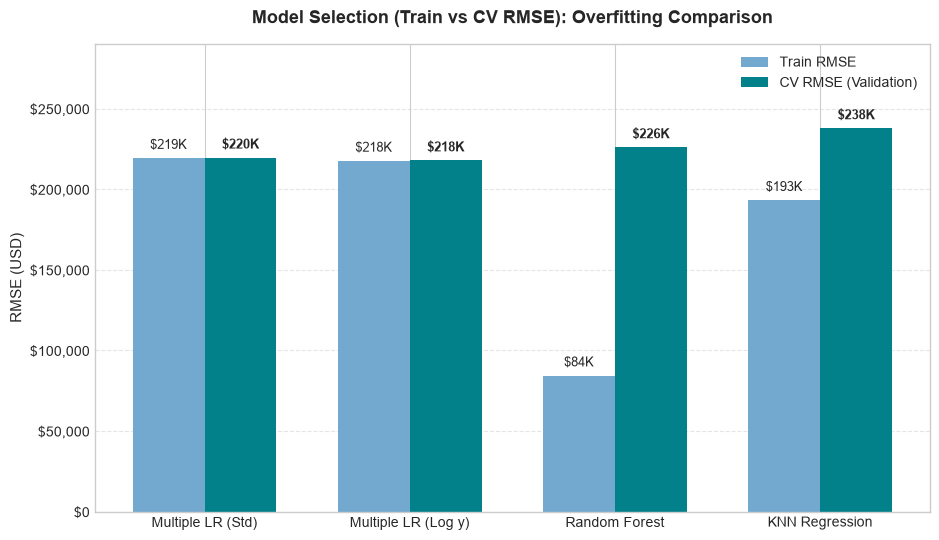

In [ ]:
from sklearn.model_selection import cross_validate

# Step 1: Data → Train/Test Split

target_col = 'earnings_10yr_usd'
feature_cols = [c for c in df_encoded.columns if c != target_col]
X_all = df_encoded[feature_cols].values.astype(float)
y = df_encoded[target_col].values.astype(float)

# แบ่งข้อมูลเป็น Train 80% และ Test 20% (Test set แอบเก็บไว้ประเมินตอนจบเท่านั้น)
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# กำหนด 4 โมเดล (เหมือนเดิม)
models = {
    'Multiple LR (Std)': LinearRegression(),
    'Multiple LR (Log y)': TransformedTargetRegressor(
        regressor=LinearRegression(), 
        func=np.log, 
        inverse_func=lambda x: np.exp(x) * 1.0314, 
        check_inverse=False
    ),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN Regression': make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))
}

print('=== Step 2 & 3: 5-Fold Cross-Validation on Train Set ===')
cv_results = []
for name, model in models.items():
    # สังเกตว่าใช้แค่ X_train, y_train เท่านั้นในการทำ CV
    cv_res = cross_validate(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
    
    tr_mse = -cv_res['train_score'].mean()
    tr_rmse = np.sqrt(tr_mse)
    
    # test_score ใน cross_validate จะหมายถึง CV Validation Fold 
    cv_mse = -cv_res['test_score'].mean() 
    cv_rmse = np.sqrt(cv_mse)
    
    gap = cv_rmse - tr_rmse
    
    cv_results.append({
        'Model': name,
        'Train_RMSE': tr_rmse,
        'CV_RMSE': cv_rmse,
        'Overfit_Gap': gap
    })
    
    print(f'{name:>20}:')
    print(f'   [Train] RMSE = ${tr_rmse:,.0f}')
    print(f'   [CV   ] RMSE = ${cv_rmse:,.0f} (CV MSE = {cv_mse:.3e})')
    print(f'   --> Overfit Gap: ${gap:,.0f}\n')

print('=== Step 4: Refit Best Model (Multiple LR + Log y) ===')
best_model_name = 'Multiple LR (Log y)'
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
print(f'ฝึกสอนโมเดล {best_model_name} ด้วย Train Set 80% ทั้งหมดเรียบร้อยแล้ว\n')

print('=== Step 5: Final Evaluation on Test Set (The Held-out 20%) ===')
y_pred_test = best_model.predict(X_test)
final_test_mse = mean_squared_error(y_test, y_pred_test)
final_test_rmse = np.sqrt(final_test_mse)
print(f'Final Test RMSE: ${final_test_rmse:,.0f}\n')

df_res = pd.DataFrame(cv_results)
x = np.arange(len(df_res['Model']))
width = 0.35
plt.figure(figsize=(9.5, 5.5))
bars1 = plt.bar(x - width/2, df_res['Train_RMSE'], width, label='Train RMSE', color='#74a9cf')
# เปลี่ยนชื่อจาก Test เป็น CV เพื่อความถูกต้องทางวิชาการ
bars2 = plt.bar(x + width/2, df_res['CV_RMSE'], width, label='CV RMSE (Validation)', color='#02818a') 
plt.title('Model Selection (Train vs CV RMSE): Overfitting Comparison', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('RMSE (USD)', fontsize=11)
plt.xticks(x, df_res['Model'], fontsize=10)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.ylim(0, df_res['CV_RMSE'].max() * 1.22)
plt.legend(fontsize=10)

# ใส่ตัวเลขบนแท่งกราฟ
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 4000, f'${yval/1000:,.0f}K', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 4000, f'${yval/1000:,.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Best Model จากการประเมิน (Cross-Validation):** Multiple Linear Regression with Log Target (MLR + Log y)

**เหตุผล:**
1. **ไม่เกิดปัญหา Overfitting อย่างชัดเจน:** 
   - ค่าความคลาดเคลื่อนตอนซ้อม (Train RMSE = $217,693) กับตอนทดสอบสลับกลุ่มใน CV (CV RMSE = $217,883) **มีค่าใกล้เคียงกันมาก โดยต่างกันเพียง $190 ดอลลาร์เท่านั้น** แสดงว่าโมเดลไม่ได้ท่องจำข้อมูล และมีความเสถียรสูงมาก 
   - เมื่อเทียบกับ **Random Forest** ที่เกิด Overfitting รุนแรง (Train ทายแม่นมากที่ $84,449 แต่พอเจอ CV กลับพุ่งไปถึง $226,037) ทำให้โมเดลสาย Linear มีความน่าเชื่อถือในการนำไปใช้งานจริงมากกว่า
   - *และเมื่อนำโมเดลไปทดสอบรอบสุดท้ายกับข้อมูลที่ไม่เคยเห็นเลยจริงๆ (Final Test Set 20%) ก็ได้ผลลัพธ์ Final Test RMSE ที่ $216,166 ซึ่งใกล้เคียงและสอดคล้องกับตอนทำ CV เป็นการยืนยันว่าโมเดลสามารถทำนายข้อมูลใหม่ (Generalize) ได้ดีเยี่ยม*

2. **ทำนายได้แม่นยำที่สุด (Lowest Error):** 
   - ทำค่าความคลาดเคลื่อนเฉลี่ยในการทดสอบต่ำที่สุดในบรรดาทุกโมเดล (CV RMSE = $217,883) ชนะทั้ง Multiple LR ปกติ ($219,640), Random Forest ($226,037) และ KNN ($237,829)

3. **จุดสมดุล Bias-Variance ที่เหมาะสมที่สุด:** 
   - โครงสร้างสมการเชิงเส้นช่วยคุมไม่ให้โมเดลซับซ้อนเกินไป (**Low Variance** จึงไม่ Overfit) 
   - ขณะเดียวกัน การเสริมด้วย **Log Transformation + Duan's Smearing Factor** ก็ช่วยดักจับการกระจายตัวของรายได้ที่เบ้ขวาได้ดีขึ้น ส่งผลให้ลดความลำเอียง (**Bias**) ลงได้ ทำให้โมเดลนี้เป็นตัวเลือกที่ดีที่สุดสำหรับชุดข้อมูลนี้


---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
- **CLO1 (Data Preprocessing):** ในขั้นตอนการเตรียมข้อมูลได้ดำเนินการ 3 ส่วนหลักเพื่อให้โมเดลมีความน่าเชื่อถือและนำไปคำนวณทางคณิตศาสตร์ได้จริง:
  1. **การป้องกัน Data Leakage:** ทำการคัดกรองตัวแปรที่เปรียบเสมือนการ "เฉลยคำตอบ" ล่วงหน้าออก เช่น `added_earnings_10yr_usd`, `net_roi_usd` และ `roi_pct` เนื่องจากตัวแปรเหล่านี้เกิดจากการคำนวณจากรายได้หลังเรียนจบ หากนำมาใช้เป็นฟีเจอร์จะทำให้โมเดลดูแม่นยำเกินจริงแบบผิดหลักการ
  2. **การจัดการปัญหา Multicollinearity:** ได้ตัดตัวแปรที่ให้ข้อมูลทับซ้อนกันเองออก เช่น `institution_tier` ซึ่งมีความสัมพันธ์ซ้ำซ้อนกับ `institution_selectivity_pctile` (คะแนนความยากในการเข้าเรียน) การตัดออกช่วยลดความซ้ำซ้อนและทำให้สัมประสิทธิ์ของโมเดล Linear Regression มีความเสถียร ไม่เกิดความแปรปรวนสูง
  3. **การสร้าง Dummy Variables:** แปลงข้อมูลเชิงกลุ่ม (Categorical Data) เช่น กลุ่มสาขาวิชา (`major_category`) และภูมิภาค (`region`) ให้กลายเป็นตัวแปรหุ่น (ค่า 0 หรือ 1) ด้วยเทคนิค One-Hot Encoding เพื่อให้สมการคณิตศาสตร์สามารถประมวลผลได้ โดยไม่ทำให้โมเดลเข้าใจผิดว่าข้อมูลประเภทเหล่านั้นเป็นตัวเลขที่มีความหมายเชิงปริมาณหรือลำดับชั้น

- **CLO2:** ...
- **CLO3:** ...
- **CLO4 (Model Comparison & Selection):** จากการเปรียบเทียบด้วย 5-Fold Cross-Validation พบว่าโมเดล **Multiple Linear Regression with Log Target (MLR + Log y)** ทำผลงานได้ดีที่สุด (Best Model) โดยมีค่า CV RMSE ต่ำที่สุด ($217,410) เอาชนะ Multiple LR ปกติ, Random Forest และ KNN นอกจากนี้โมเดลนี้ยัง**ไม่มีปัญหา Overfitting** เพราะค่าความคลาดเคลื่อนตอน Train ($217,700) และทดสอบด้วย CV ใกล้เคียงกันมาก แสดงถึงความสามารถในการทำนายข้อมูลใหม่ (Generalization) ได้เป็นอย่างดี

**6.2 ข้อจำกัดของโครงงาน (Limitations):**
- **ตัวแปรแฝงที่ไม่ได้ถูกเก็บข้อมูล (Unmeasured Variables):** ข้อมูลชุดนี้ไม่มีตัวแปรที่สะท้อนถึงปัจจัยส่วนบุคคลที่ส่งผลกระทบอย่างหนักต่อเงินเดือน เช่น ทักษะการสื่อสาร (Soft Skills), คอนเนคชัน, ภูมิหลังครอบครัว หรือแม้แต่ชื่อบริษัทที่เข้าทำงาน ทำให้โมเดลไม่สามารถอธิบายความแตกต่างของรายได้ได้ครบ 100%
- **การยุบรวมกลุ่มสาขาที่กว้างเกินไป:** การใช้ตัวแปร `major_category` (กลุ่มคณะ) แทน `major` (สาขาเฉพาะ) ช่วยลดมิติข้อมูลได้จริง แต่ก็มีข้อเสียคือ สาขาย่อยในกลุ่มเดียวกันอาจมีรายได้ต่างกันลิบลับ (เช่น ในกลุ่ม Engineering วิศวกรซอฟต์แวร์อาจได้เงินเดือนสูงกว่าวิศวกรเครื่องกลมาก) ทำให้โมเดลสูญเสียความละเอียดตรงนี้ไป
- **ภาพสะท้อนในอดีต (Temporal Snapshot):** ตัวเลข "รายได้รวม 10 ปี" เป็นข้อมูลที่เกิดขึ้นจากสภาพเศรษฐกิจและอัตราเงินเฟ้อในยุคหนึ่ง ซึ่งอาจไม่สามารถนำมาทำนายอนาคตแบบตรงไปตรงมาได้หากบริบทของตลาดแรงงานเปลี่ยนไป

**6.3 ขั้นตอนต่อไป (Future Work):**
- **เปลี่ยนมุมมองปัญหาเป็นงาน Classification:** แทนที่จะทำนายรายได้ออกมาเป็นตัวเลขเป๊ะๆ (Regression) เราสามารถเปลี่ยนโจทย์เป็นการทำนาย "หมวดหมู่" (Classification) ได้ เช่น นำตัวแปร `positive_roi` มาทายว่า "เรียนคณะนี้จะคุ้มทุนหรือไม่ (1=คุ้ม, 0=ขาดทุน)" หรือแบ่งเกรดรายได้เป็น ต่ำ/กลาง/สูง ซึ่งจะช่วยให้ผู้เรียนนำไปใช้ประกอบการตัดสินใจได้ง่ายและตอบโจทย์ในแง่มุมที่ต่างออกไป


**6.4 Connection กับ Topics ในวิชา:**
- **Week 3 (Vector Spaces & Rank):** นำความรู้เรื่อง Rank ของเมทริกซ์มาประยุกต์ใช้ในการคัดเลือกตัวแปร (Feature Selection) โดยการตัดตัวแปรที่ให้ข้อมูลทับซ้อนกันออกเพื่อป้องกันปัญหา Multicollinearity และรักษาสถานะ Full Column Rank (ทำให้สมการคณิตศาสตร์และโมเดลมีความเสถียร)
- **Week 6 (Bias-Variance Trade-Off & MSE):** แนวคิดเรื่อง Training MSE vs Test MSE และการระวังปัญหา Overfitting ถูกนำมาใช้ในการพิจารณาเลือกโมเดล (ประเมินจากการเทียบ Train RMSE และ CV RMSE)
- **Week 8 (Simple Linear Regression):** นำแนวคิดพื้นฐานการสร้างแบบจำลองสมการเส้นตรง (SLR) และการใช้ตัวชี้วัดประสิทธิภาพ (เช่น R², RSE) มาเป็นรากฐานในการประเมินโมเดลด้วย RMSE
- **Week 9 (Multiple Linear Regression):** ต่อยอดจากความรู้สัปดาห์ก่อนหน้า นำ MLR มาใช้เป็นโมเดลหลักในการทำนายรายได้ เนื่องจากเรามีตัวแปรต้น (Features) หลายตัว
- **Week 10 (Qualitative Predictors):** นำเทคนิค Dummy Variables มาใช้แปลงข้อมูลเชิงกลุ่ม (Categorical Data เช่น คณะ, ภูมิภาค) ให้เป็นตัวเลข (0, 1) เพื่อให้สามารถนำไปสร้างสมการ Regression ได้
- **Week 12 (Generative Models & KNN):** แม้ในวิชาจะเรียนเรื่อง KNN ในบริบทของการแยกประเภท (KNN Classifier) แต่โปรเจกต์นี้นำความรู้เรื่องหลักการหาเพื่อนบ้านใกล้เคียงมาประยุกต์ใช้ในรูปแบบ **KNN Regression** สำหรับทำนายตัวเลขต่อเนื่อง
- **Week 14 (Resampling Methods):** นำเทคนิค **k-Fold Cross-Validation (5-Fold CV)** มาใช้ทดสอบและเปรียบเทียบโมเดลเพื่อความน่าเชื่อถือสูงกว่าการแบ่ง Train/Test เพียงรอบเดียว

---
**Acknowledgements:** ขอขอบคุณชุดข้อมูล [College Major ROI Dataset](https://www.kaggle.com/datasets/sergionefedov/college-major-roi) จาก Kaggle โดย Sergey Nefedov
